In [1]:
import importlib.util, subprocess, sys
if importlib.util.find_spec("yaml") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyyaml"])

In [2]:
!git clone https://github.com/alihasnaink/beyond-iid.git

Cloning into 'beyond-iid'...
remote: Enumerating objects: 149, done.
remote: Counting objects: 100% (149/149), done.
remote: Compressing objects: 100% (117/117), done.
remote: Total 149 (delta 36), reused 132 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (149/149), 38.33 MiB | 27.31 MiB/s, done.
Resolving deltas: 100% (36/36), done.


In [ ]:
from pathlib import Path
import subprocess
import sys
from IPython.display import Image as DisplayImage, display
def locate_repo_root():
    starts = [Path.cwd().resolve(), Path("/kaggle/working/beyond-iid")]
    seen = set()
    for start in starts:
        for candidate in (start, *start.parents):
            for root in (candidate, candidate / "beyond-iid"):
                root = root.resolve()
                if root in seen:
                    continue
                seen.add(root)
                if (root / "shared/pacs.py").is_file() and (root / "domain-generalization/train.py").is_file():
                    return root
    raise FileNotFoundError(
        "Could not locate beyond-iid. Clone it under /kaggle/working or run this notebook from the repository."
    )
REPO_ROOT = locate_repo_root()
TASK_DIR = REPO_ROOT / "domain-generalization"
TASK2_DIR = REPO_ROOT / "domain-adaptation"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from shared.pacs import find_pacs_root
PACS_ROOT = "/kaggle/input/datasets/nickfratto/pacs-dataset/pacs_data/pacs_data"
resolved_pacs_root = find_pacs_root(PACS_ROOT)
task2_checkpoint = REPO_ROOT / "shared/checkpoints/source_only_pacs_sketch_seed6304.pt"
task2_history = TASK2_DIR / "results/histories/source_only.csv"
if not task2_checkpoint.is_file() or not task2_history.is_file():
    print("Task 2 ERM artifact is missing; regenerating only Source-only in an isolated process.", flush=True)
    recovery_code = r'''
import sys
from pathlib import Path
repo_root = Path(sys.argv[1]).resolve()
task_dir = repo_root / "domain-adaptation"
pacs_root = Path(sys.argv[2]).resolve()
sys.path.insert(0, str(repo_root))
sys.path.insert(0, str(task_dir))
import train as task2_train
assert Path(task2_train.__file__).resolve() == task_dir / "train.py", task2_train.__file__
task2_train.MAIN_METHODS[:] = ["source_only"]
task2_train.train_suite(pacs_root, task_dir, include_study=False, force=False)
'''
    subprocess.run(
        [sys.executable, "-c", recovery_code, str(REPO_ROOT), str(resolved_pacs_root)],
        check=True,
    )
assert task2_checkpoint.is_file(), f"Task 2 checkpoint was not created: {task2_checkpoint}"
assert task2_history.is_file(), f"Task 2 history was not created: {task2_history}"
for module_name in (
    "train", "configs", "models", "methods", "training", "evaluation",
    "selection", "evaluate_source", "evaluate_sketch",
):
    module = sys.modules.get(module_name)
    module_file = getattr(module, "__file__", None) if module else None
    if module_file and TASK_DIR not in Path(module_file).resolve().parents:
        raise RuntimeError(
            f"{module_name!r} was already imported from {module_file}. "
            "Restart the kernel and run this notebook from the first cell."
        )
for path in (str(REPO_ROOT), str(TASK_DIR)):
    if path in sys.path:
        sys.path.remove(path)
    sys.path.insert(0, path)
import train as task3_train
assert Path(task3_train.__file__).resolve() == TASK_DIR / "train.py", task3_train.__file__
from evaluate_source import evaluate_source_suite
from evaluate_sketch import evaluate_sketch_suite
train_suite = task3_train.train_suite
print({
    "repo_root": str(REPO_ROOT),
    "task_dir": str(TASK_DIR),
    "pacs_root": str(resolved_pacs_root),
    "train_module": str(Path(task3_train.__file__).resolve()),
    "task2_checkpoint_ready": task2_checkpoint.is_file(),
})

Task 2 ERM artifact is missing; regenerating only Source-only in an isolated process.
PACS root: /kaggle/input/datasets/nickfratto/pacs-dataset/pacs_data/pacs_data | device: cuda | runs: 1
Source train images: {'photo': 1336, 'art_painting': 1638, 'cartoon': 1875} | source validation images: {'photo': 334, 'art_painting': 410, 'cartoon': 469}
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 233MB/s]


[1/1] source_only: training


  source_only epoch 1/30: loss=0.5195, source-val macro-F1=0.8893, best=0.8893


  source_only epoch 2/30: loss=0.2172, source-val macro-F1=0.8359, best=0.8893


...

  source_only epoch 6/30: loss=0.0850, source-val macro-F1=0.9175, best=0.9288


  source_only epoch 7/30: loss=0.0589, source-val macro-F1=0.8981, best=0.9288


  source_only epoch 8/30: loss=0.0673, source-val macro-F1=0.9063, best=0.9288


  source_only epoch 9/30: loss=0.0566, source-val macro-F1=0.9245, best=0.9288


  source_only epoch 10/30: loss=0.0803, source-val macro-F1=0.9169, best=0.9288
{'repo_root': '/kaggle/working/beyond-iid', 'task_dir': '/kaggle/working/beyond-iid/domain-generalization', 'pacs_root': '/kaggle/input/datasets/nickfratto/pacs-dataset/pacs_data/pacs_data', 'train_module': '/kaggle/working/beyond-iid/domain-generalization/train.py', 'task2_checkpoint_ready': True}


Task 3 source-only training | device: cuda | runs: 5
Source train images: {'photo': 1336, 'art_painting': 1638, 'cartoon': 1875} | source validation images: {'photo': 334, 'art_painting': 410, 'cartoon': 469}
Sketch images are not loaded by this stage.
[1/5] erm: reusing unchanged Task 2 checkpoint
[2/5] dan_dg: training


dan_dg epoch 1/30:   0%|          | 0/234 [00:00<?, ?it/s]

  dan_dg epoch 1/30: loss=2.4088, mean-source macro-F1=0.0507, best=0.0507


dan_dg epoch 2/30:   0%|          | 0/234 [00:00<?, ?it/s]

  dan_dg epoch 2/30: loss=2.2980, mean-source macro-F1=0.0507, best=0.0507


...

  sam_rho_0p1 epoch 29/30: loss=0.1349, mean-source macro-F1=0.9315, best=0.9359


sam_rho_0p1 epoch 30/30:   0%|          | 0/234 [00:00<?, ?it/s]

  sam_rho_0p1 epoch 30/30: loss=0.0986, mean-source macro-F1=0.9216, best=0.9359


,run_name,method,main_comparison,checkpoint,alignment_weight,rho,uses_sketch_during_training_or_selection
0,erm,erm,True,/kaggle/working/beyond-iid/shared/checkpoints/...,NaN,NaN,False
1,dan_dg,dan_dg,True,/kaggle/working/beyond-iid/domain-generalizati...,1.0,NaN,False
2,sam,sam,True,/kaggle/working/beyond-iid/domain-generalizati...,NaN,0.05,False
3,sam_rho_0p01,sam,False,/kaggle/working/beyond-iid/domain-generalizati...,NaN,0.01,False
4,sam_rho_0p1,sam,False,/kaggle/working/beyond-iid/domain-generalizati...,NaN,0.10,False


,method,epoch,mean_source_val_macro_f1,classification_loss,alignment_loss,total_loss,domain_accuracy,val_photo_accuracy,val_photo_macro_f1,val_art_painting_accuracy,val_art_painting_macro_f1,val_cartoon_accuracy,val_cartoon_macro_f1,mean_source_accuracy,worst_source_accuracy,mean_source_macro_f1,worst_source_macro_f1
9,erm,10,0.9169,0.0803,0.0000,0.0803,0.0,0.9371,0.9298,0.8854,0.8836,0.9318,0.9372,NaN,NaN,NaN,NaN
15,dan_dg,6,NaN,1.9181,0.0292,1.9473,NaN,0.2575,0.0585,0.2195,0.0514,0.1727,0.0421,0.2166,0.1727,0.0507,0.0421
30,sam,15,NaN,0.0135,0.0000,0.0988,NaN,0.9790,0.9749,0.9073,0.9056,0.9680,0.9712,0.9515,0.9073,0.9506,0.9056
43,sam_rho_0p01,13,NaN,0.0212,0.0000,0.0491,NaN,0.9701,0.9641,0.9024,0.8974,0.9510,0.9568,0.9412,0.9024,0.9394,0.8974
73,sam_rho_0p1,30,NaN,0.0057,0.0000,0.0986,NaN,0.9551,0.9464,0.8780,0.8686,0.9467,0.9497,0.9266,0.8780,0.9216,0.8686


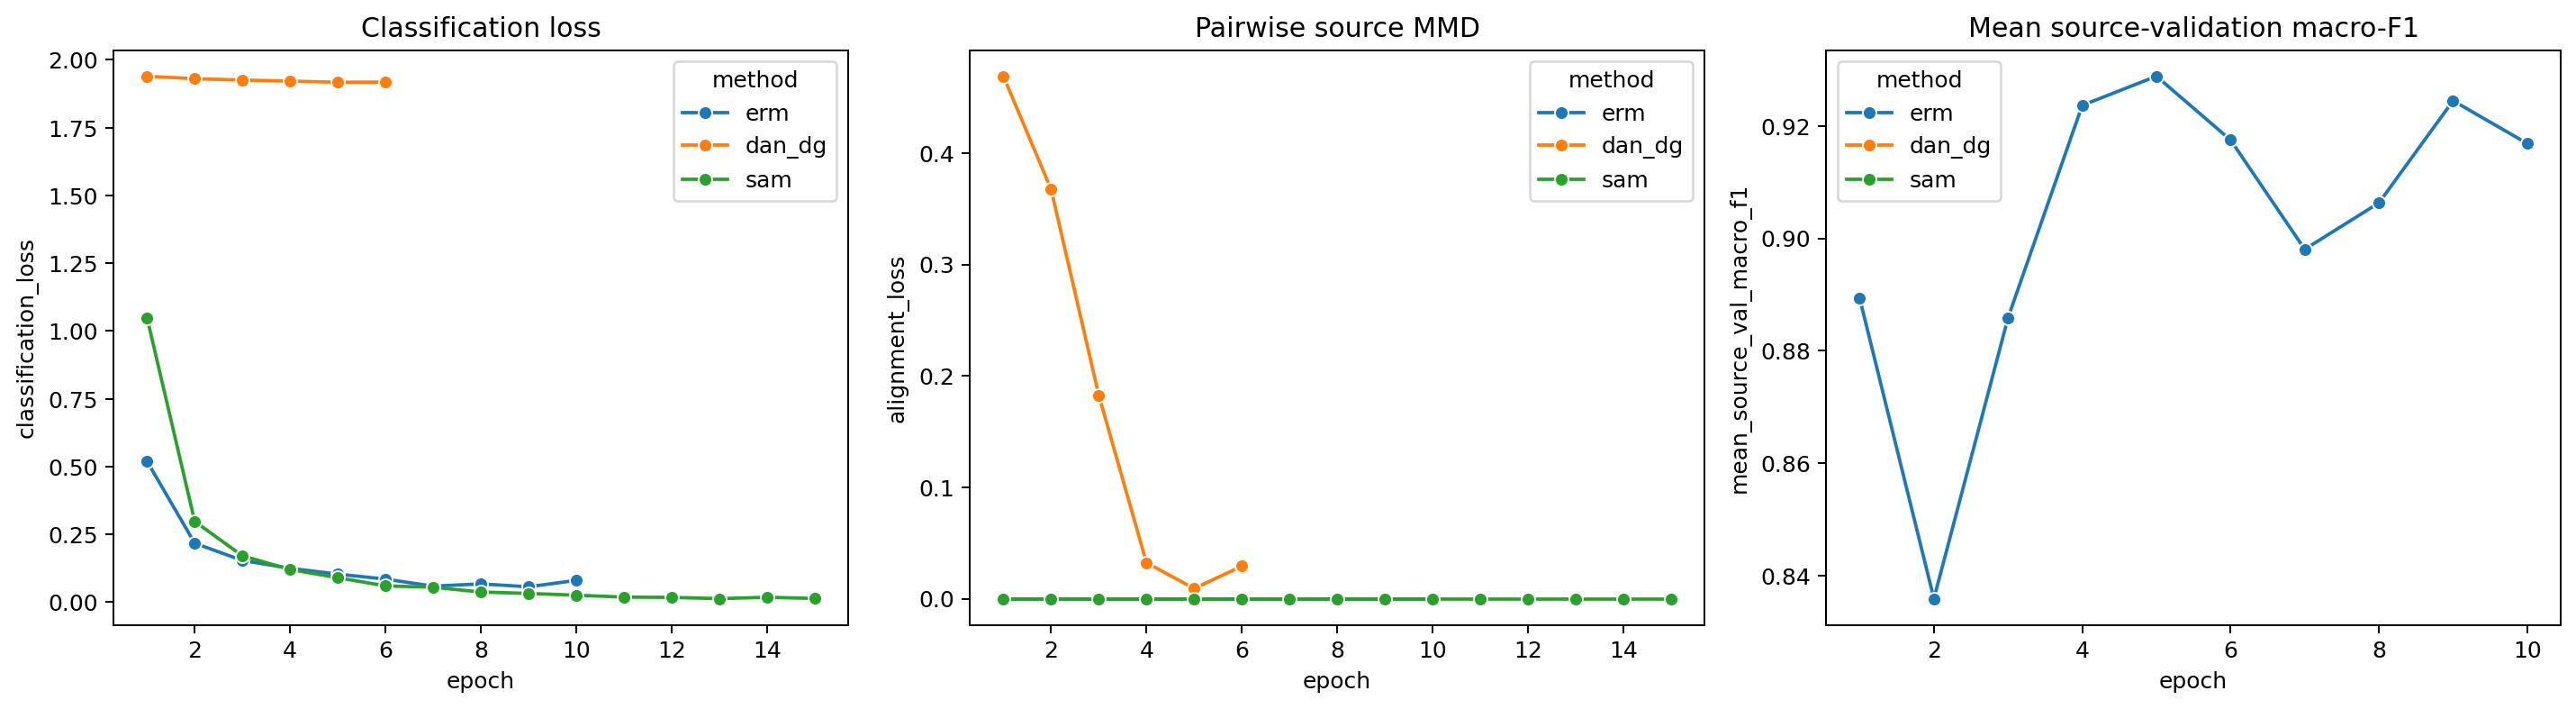

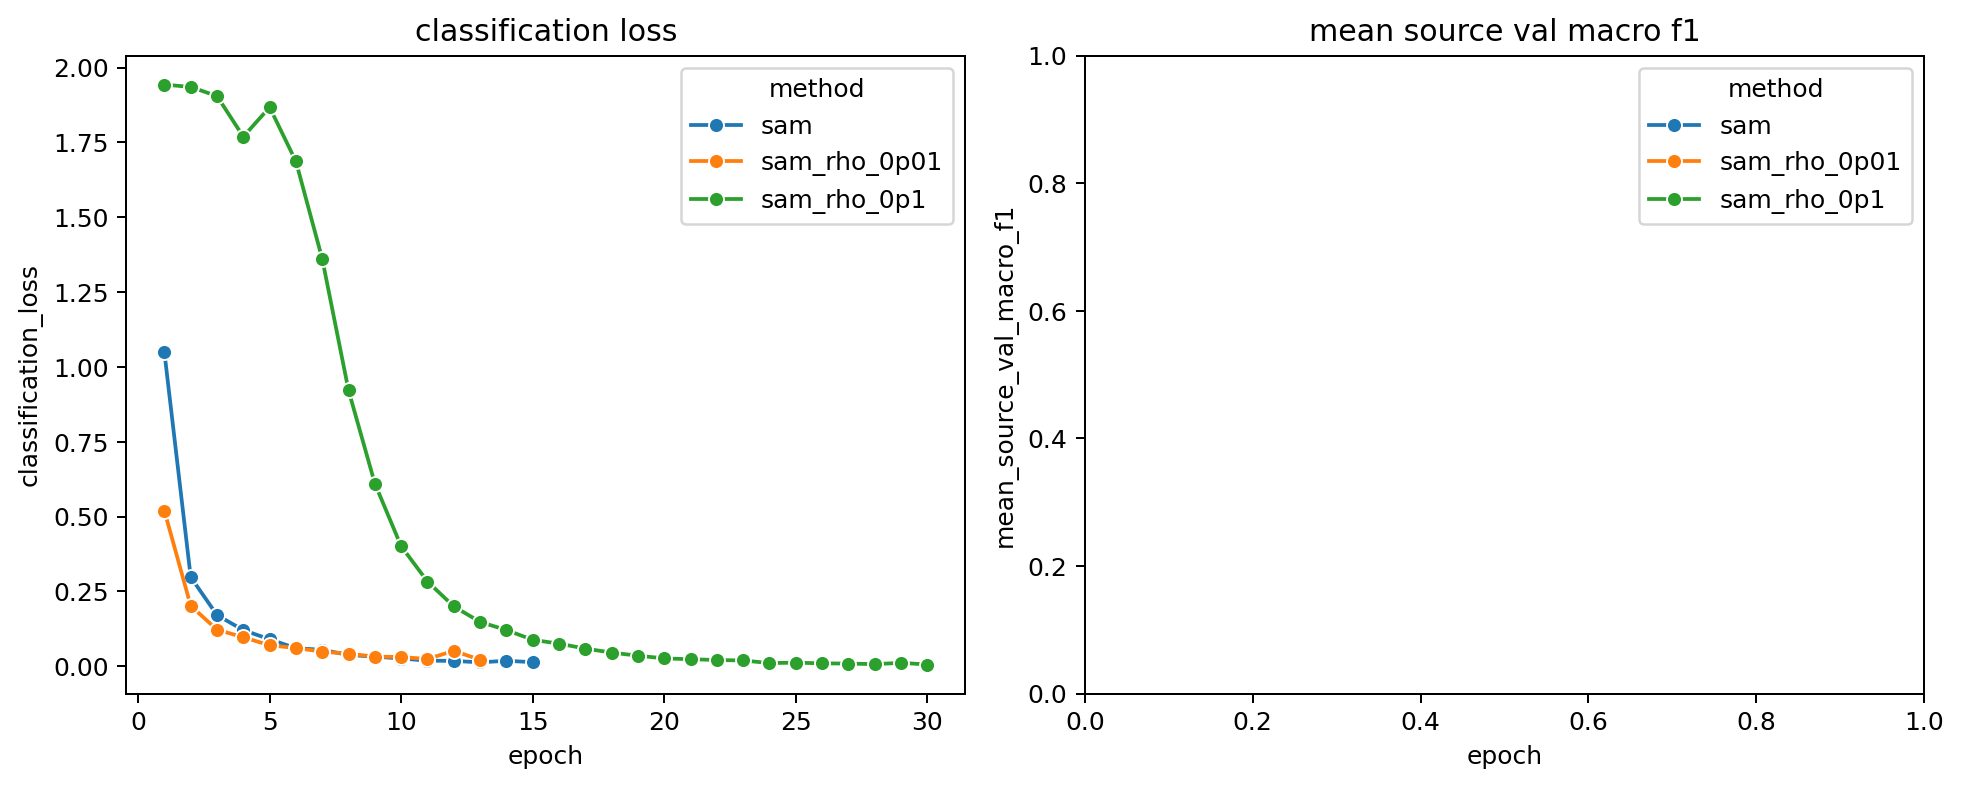

In [4]:
training = train_suite(resolved_pacs_root, TASK_DIR, include_study=True, force=False)
display(training["run_manifest"])
display(training["histories"].groupby("method").tail(1).round(4))
display(DisplayImage(filename=str(TASK_DIR / "results/main_training_curves.png"), width=1050))
display(DisplayImage(filename=str(TASK_DIR / "results/sam_radius_training_curves.png"), width=900))

[1/5] source diagnostics: erm
[2/5] source diagnostics: dan_dg
[3/5] source diagnostics: sam
[4/5] source diagnostics: sam_rho_0p01
[5/5] source diagnostics: sam_rho_0p1
Source-only diagnostics complete; Sketch has not been loaded.


,method,main_comparison,photo_accuracy,photo_macro_f1,art_painting_accuracy,art_painting_macro_f1,cartoon_accuracy,cartoon_macro_f1,mean_source_accuracy,worst_source_accuracy,mean_source_macro_f1,worst_source_macro_f1,source_domain_separability,sharpness_increase
0,erm,True,0.9671,0.9626,0.8878,0.8827,0.9339,0.9412,0.9296,0.8878,0.9288,0.8827,0.8571,0.3679
1,dan_dg,True,0.2575,0.0585,0.2195,0.0514,0.1727,0.0421,0.2166,0.1727,0.0507,0.0421,0.5515,0.0157
2,sam,True,0.9760,0.9719,0.9268,0.9250,0.9659,0.9702,0.9563,0.9268,0.9557,0.9250,0.8505,0.1637
3,sam_rho_0p01,False,0.9671,0.9598,0.9122,0.9107,0.9467,0.9511,0.9420,0.9122,0.9405,0.9107,0.8339,0.2177
4,sam_rho_0p1,False,0.9581,0.9541,0.9024,0.9022,0.9467,0.9513,0.9357,0.9024,0.9359,0.9022,0.8140,0.1302


,method,heldout_accuracy,balanced_examples_per_domain,chance_accuracy
0,erm,0.8571,334,0.3333
1,dan_dg,0.5515,334,0.3333
2,sam,0.8505,334,0.3333
3,sam_rho_0p01,0.8339,334,0.3333
4,sam_rho_0p1,0.8140,334,0.3333


,method,base_validation_loss,perturbed_validation_loss,sharpness_increase,radius,examples_per_source_domain
0,erm,0.19518,0.56311,0.36793,0.05,32
1,dan_dg,1.93099,1.94673,0.01575,0.05,32
2,sam,0.13053,0.29422,0.16369,0.05,32
3,sam_rho_0p01,0.15480,0.37248,0.21768,0.05,32
4,sam_rho_0p1,0.21683,0.34701,0.13017,0.05,32


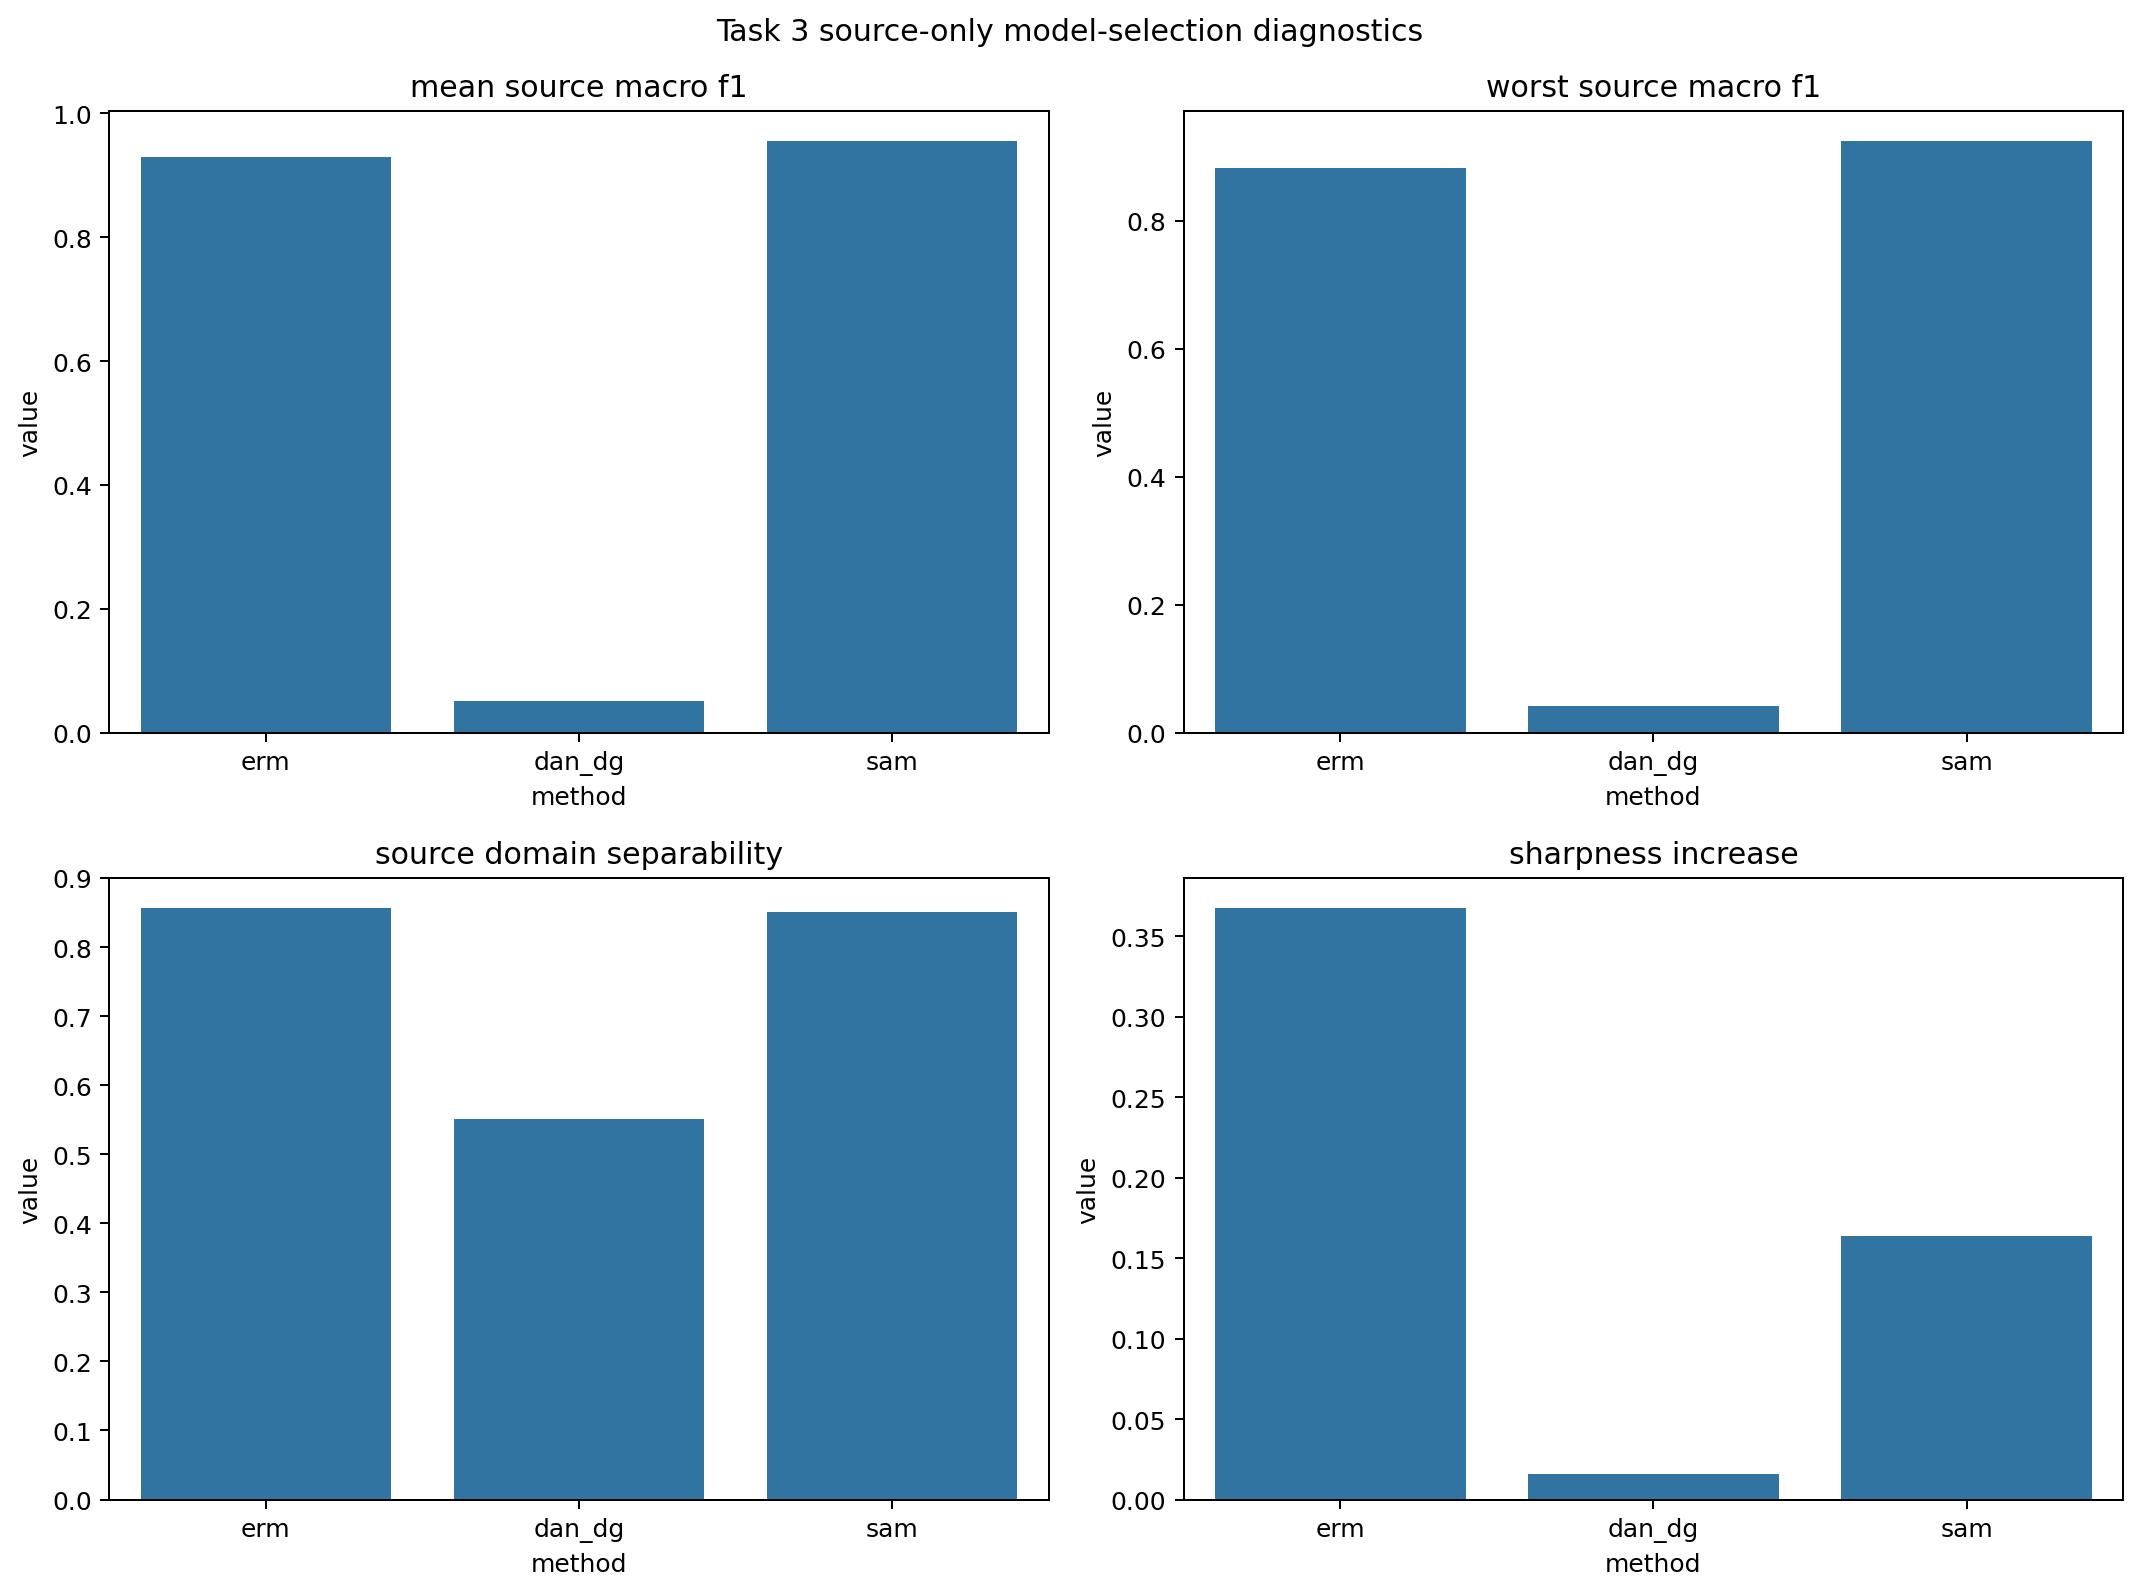

In [5]:
source_results = evaluate_source_suite(resolved_pacs_root, TASK_DIR)
display(source_results["comparison"].round(4))
display(source_results["separability"].round(4))
display(source_results["sharpness"].round(5))
display(DisplayImage(filename=str(TASK_DIR / "results/source_diagnostics.png"), width=900))

In [8]:
CONFIGURATIONS_LOCKED = True
assert CONFIGURATIONS_LOCKED, (
    "Set CONFIGURATIONS_LOCKED=True only after every Task 3 decision is frozen. "
    "The next cell is the first Task 3 operation that loads Sketch."
)

Configurations locked. Beginning final Sketch evaluation on cuda.
[1/5] Sketch evaluation: erm
[2/5] Sketch evaluation: dan_dg
[3/5] Sketch evaluation: sam
[4/5] Sketch evaluation: sam_rho_0p01
[5/5] Sketch evaluation: sam_rho_0p1


,method,main_comparison,photo_accuracy,photo_macro_f1,art_painting_accuracy,art_painting_macro_f1,cartoon_accuracy,cartoon_macro_f1,mean_source_accuracy,worst_source_accuracy,mean_source_macro_f1,worst_source_macro_f1,source_domain_separability,sharpness_increase,sketch_accuracy,sketch_macro_f1,sketch_accuracy_change_vs_erm,mean_source_to_sketch_gap
0,erm,True,0.9671,0.9626,0.8878,0.8827,0.9339,0.9412,0.9296,0.8878,0.9288,0.8827,0.8571,0.3679,0.6312,0.6436,0.0000,0.2984
1,dan_dg,True,0.2575,0.0585,0.2195,0.0514,0.1727,0.0421,0.2166,0.1727,0.0507,0.0421,0.5515,0.0157,0.0407,0.0112,-0.5905,0.1758
2,sam,True,0.9760,0.9719,0.9268,0.9250,0.9659,0.9702,0.9563,0.9268,0.9557,0.9250,0.8505,0.1637,0.7776,0.7891,0.1463,0.1787


,method,main_comparison,photo_accuracy,photo_macro_f1,art_painting_accuracy,art_painting_macro_f1,cartoon_accuracy,cartoon_macro_f1,mean_source_accuracy,worst_source_accuracy,mean_source_macro_f1,worst_source_macro_f1,source_domain_separability,sharpness_increase,sketch_accuracy,sketch_macro_f1,sketch_accuracy_change_vs_erm,mean_source_to_sketch_gap,rho
3,sam_rho_0p01,False,0.9671,0.9598,0.9122,0.9107,0.9467,0.9511,0.9420,0.9122,0.9405,0.9107,0.8339,0.2177,0.6836,0.6603,0.0524,0.2584,0.01
2,sam,True,0.9760,0.9719,0.9268,0.9250,0.9659,0.9702,0.9563,0.9268,0.9557,0.9250,0.8505,0.1637,0.7776,0.7891,0.1463,0.1787,0.05
4,sam_rho_0p1,False,0.9581,0.9541,0.9024,0.9022,0.9467,0.9513,0.9357,0.9024,0.9359,0.9022,0.8140,0.1302,0.6325,0.6429,0.0013,0.3033,0.10


,task,method,target_access_during_training,sketch_accuracy,sketch_macro_f1
0,Task 3 DG,erm,False,0.6312,0.6436
1,Task 3 DG,dan_dg,False,0.0407,0.0112


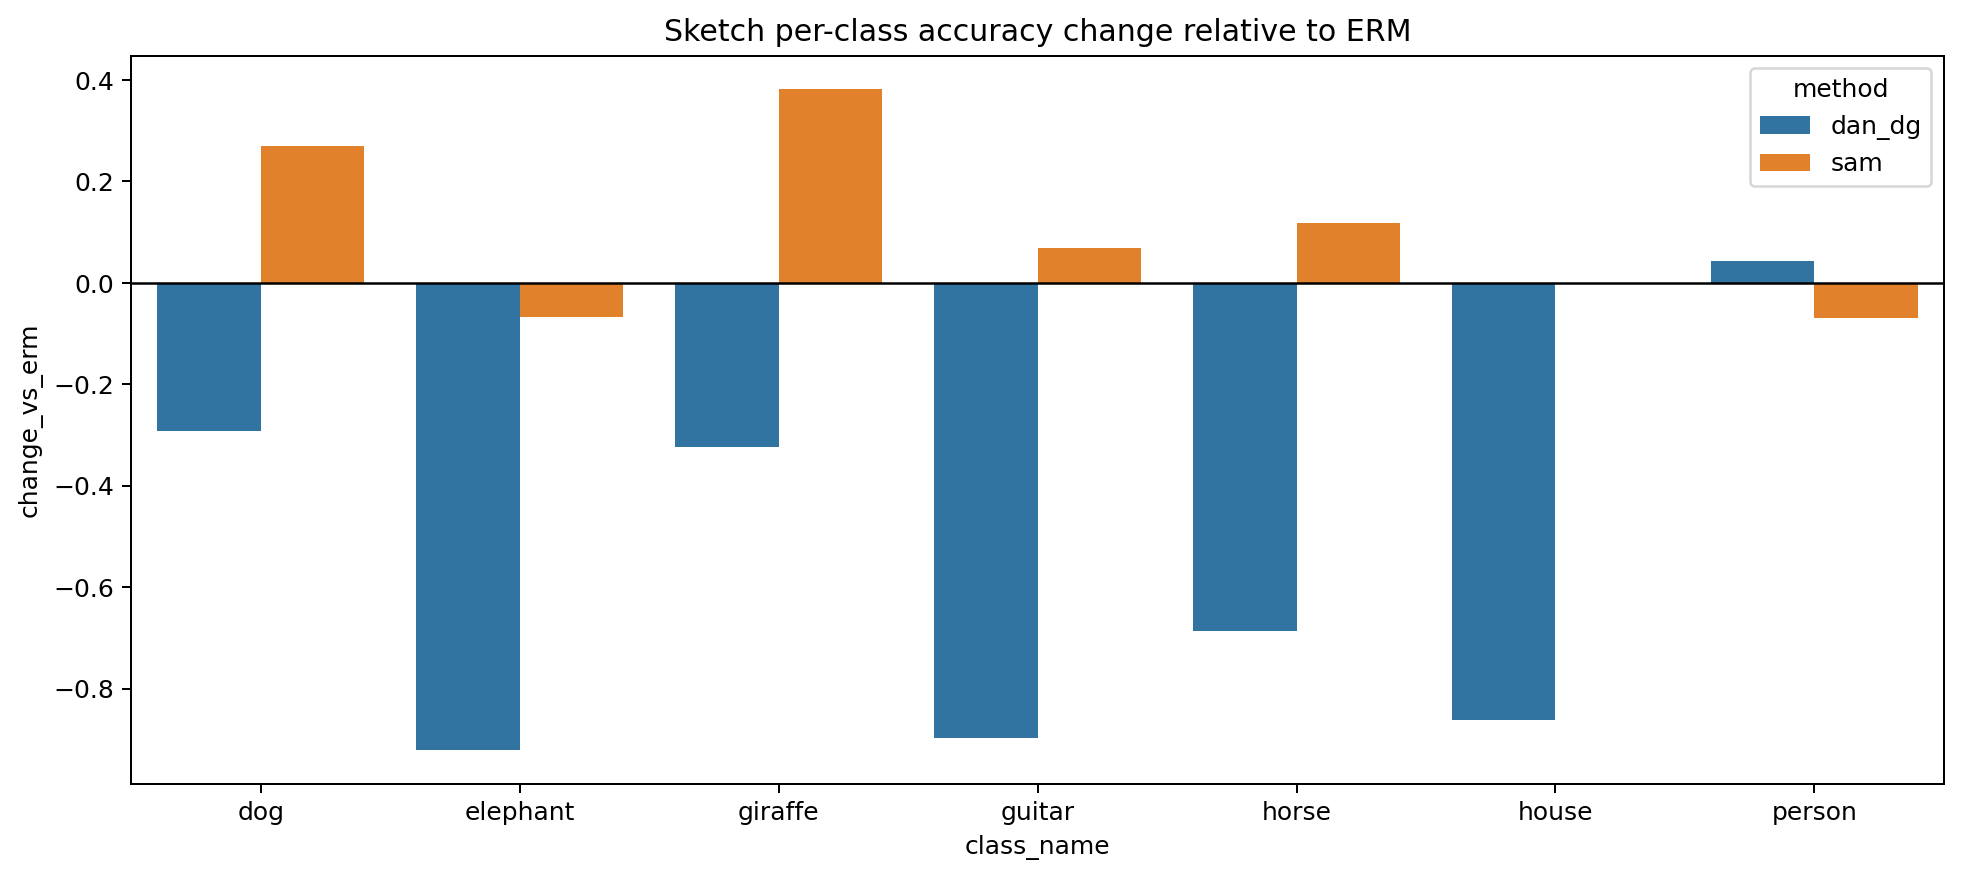

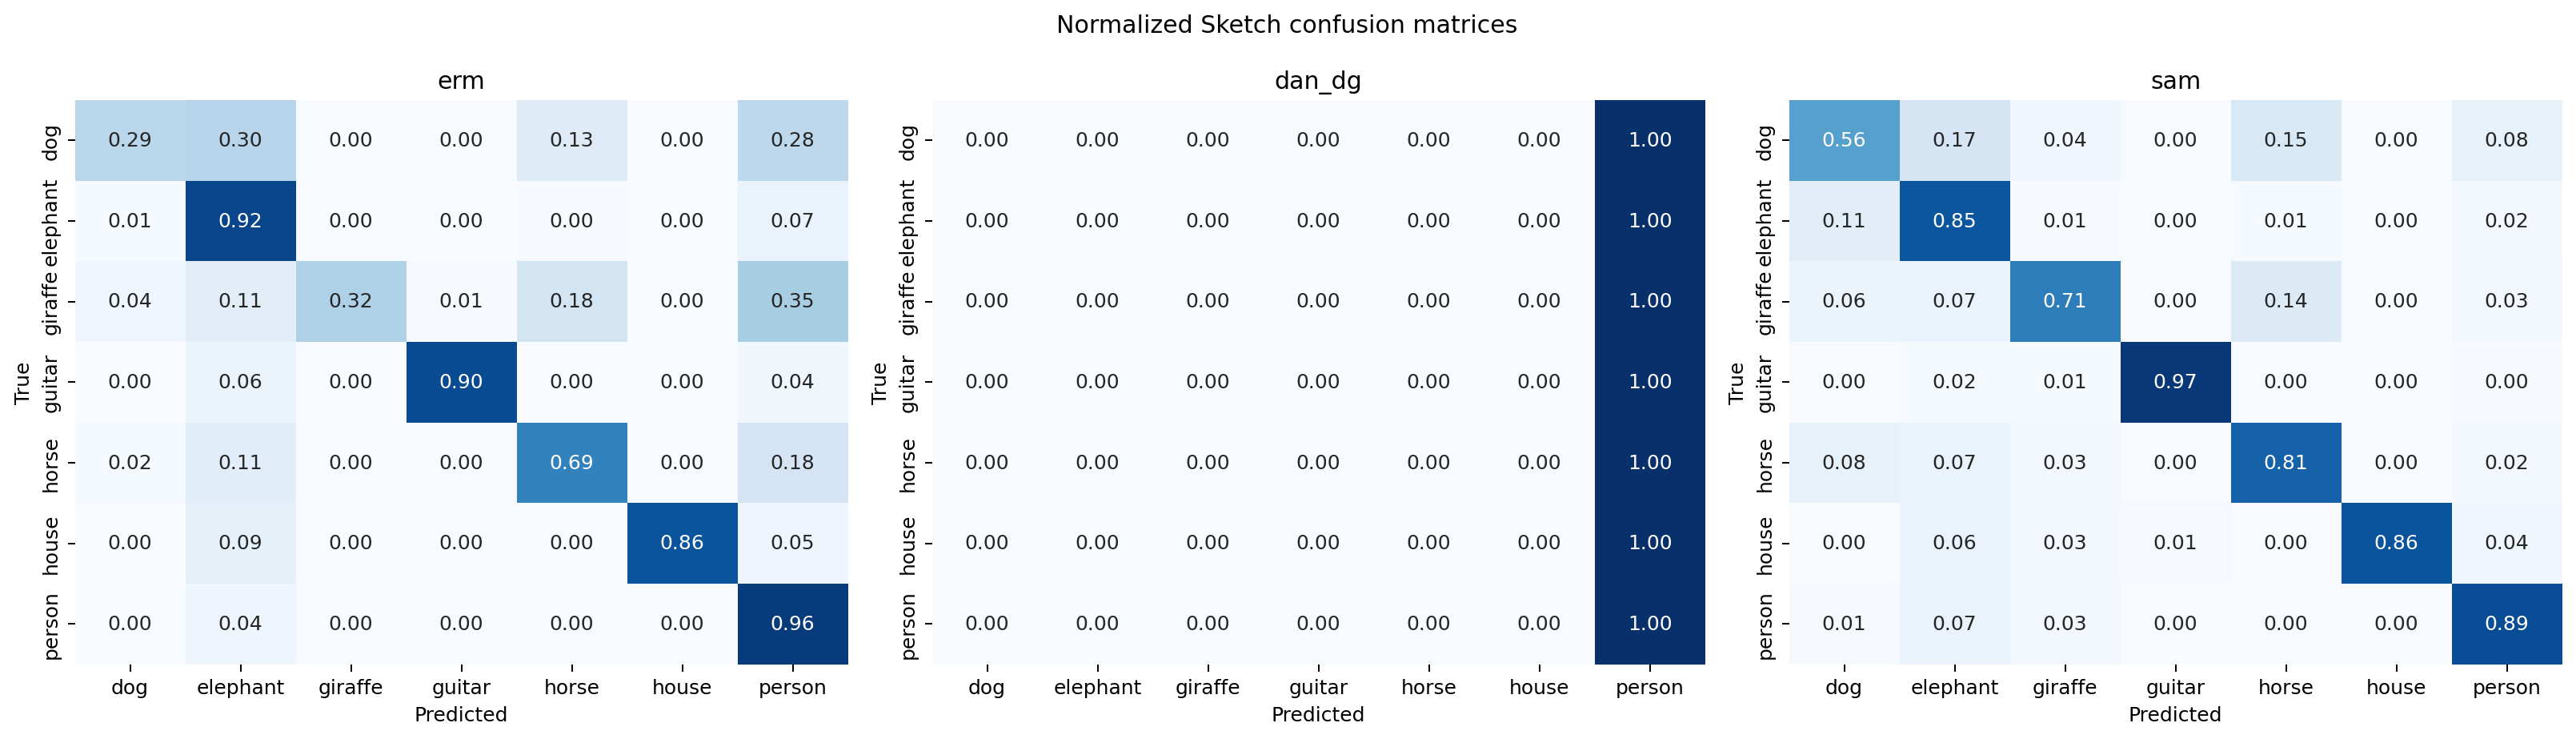

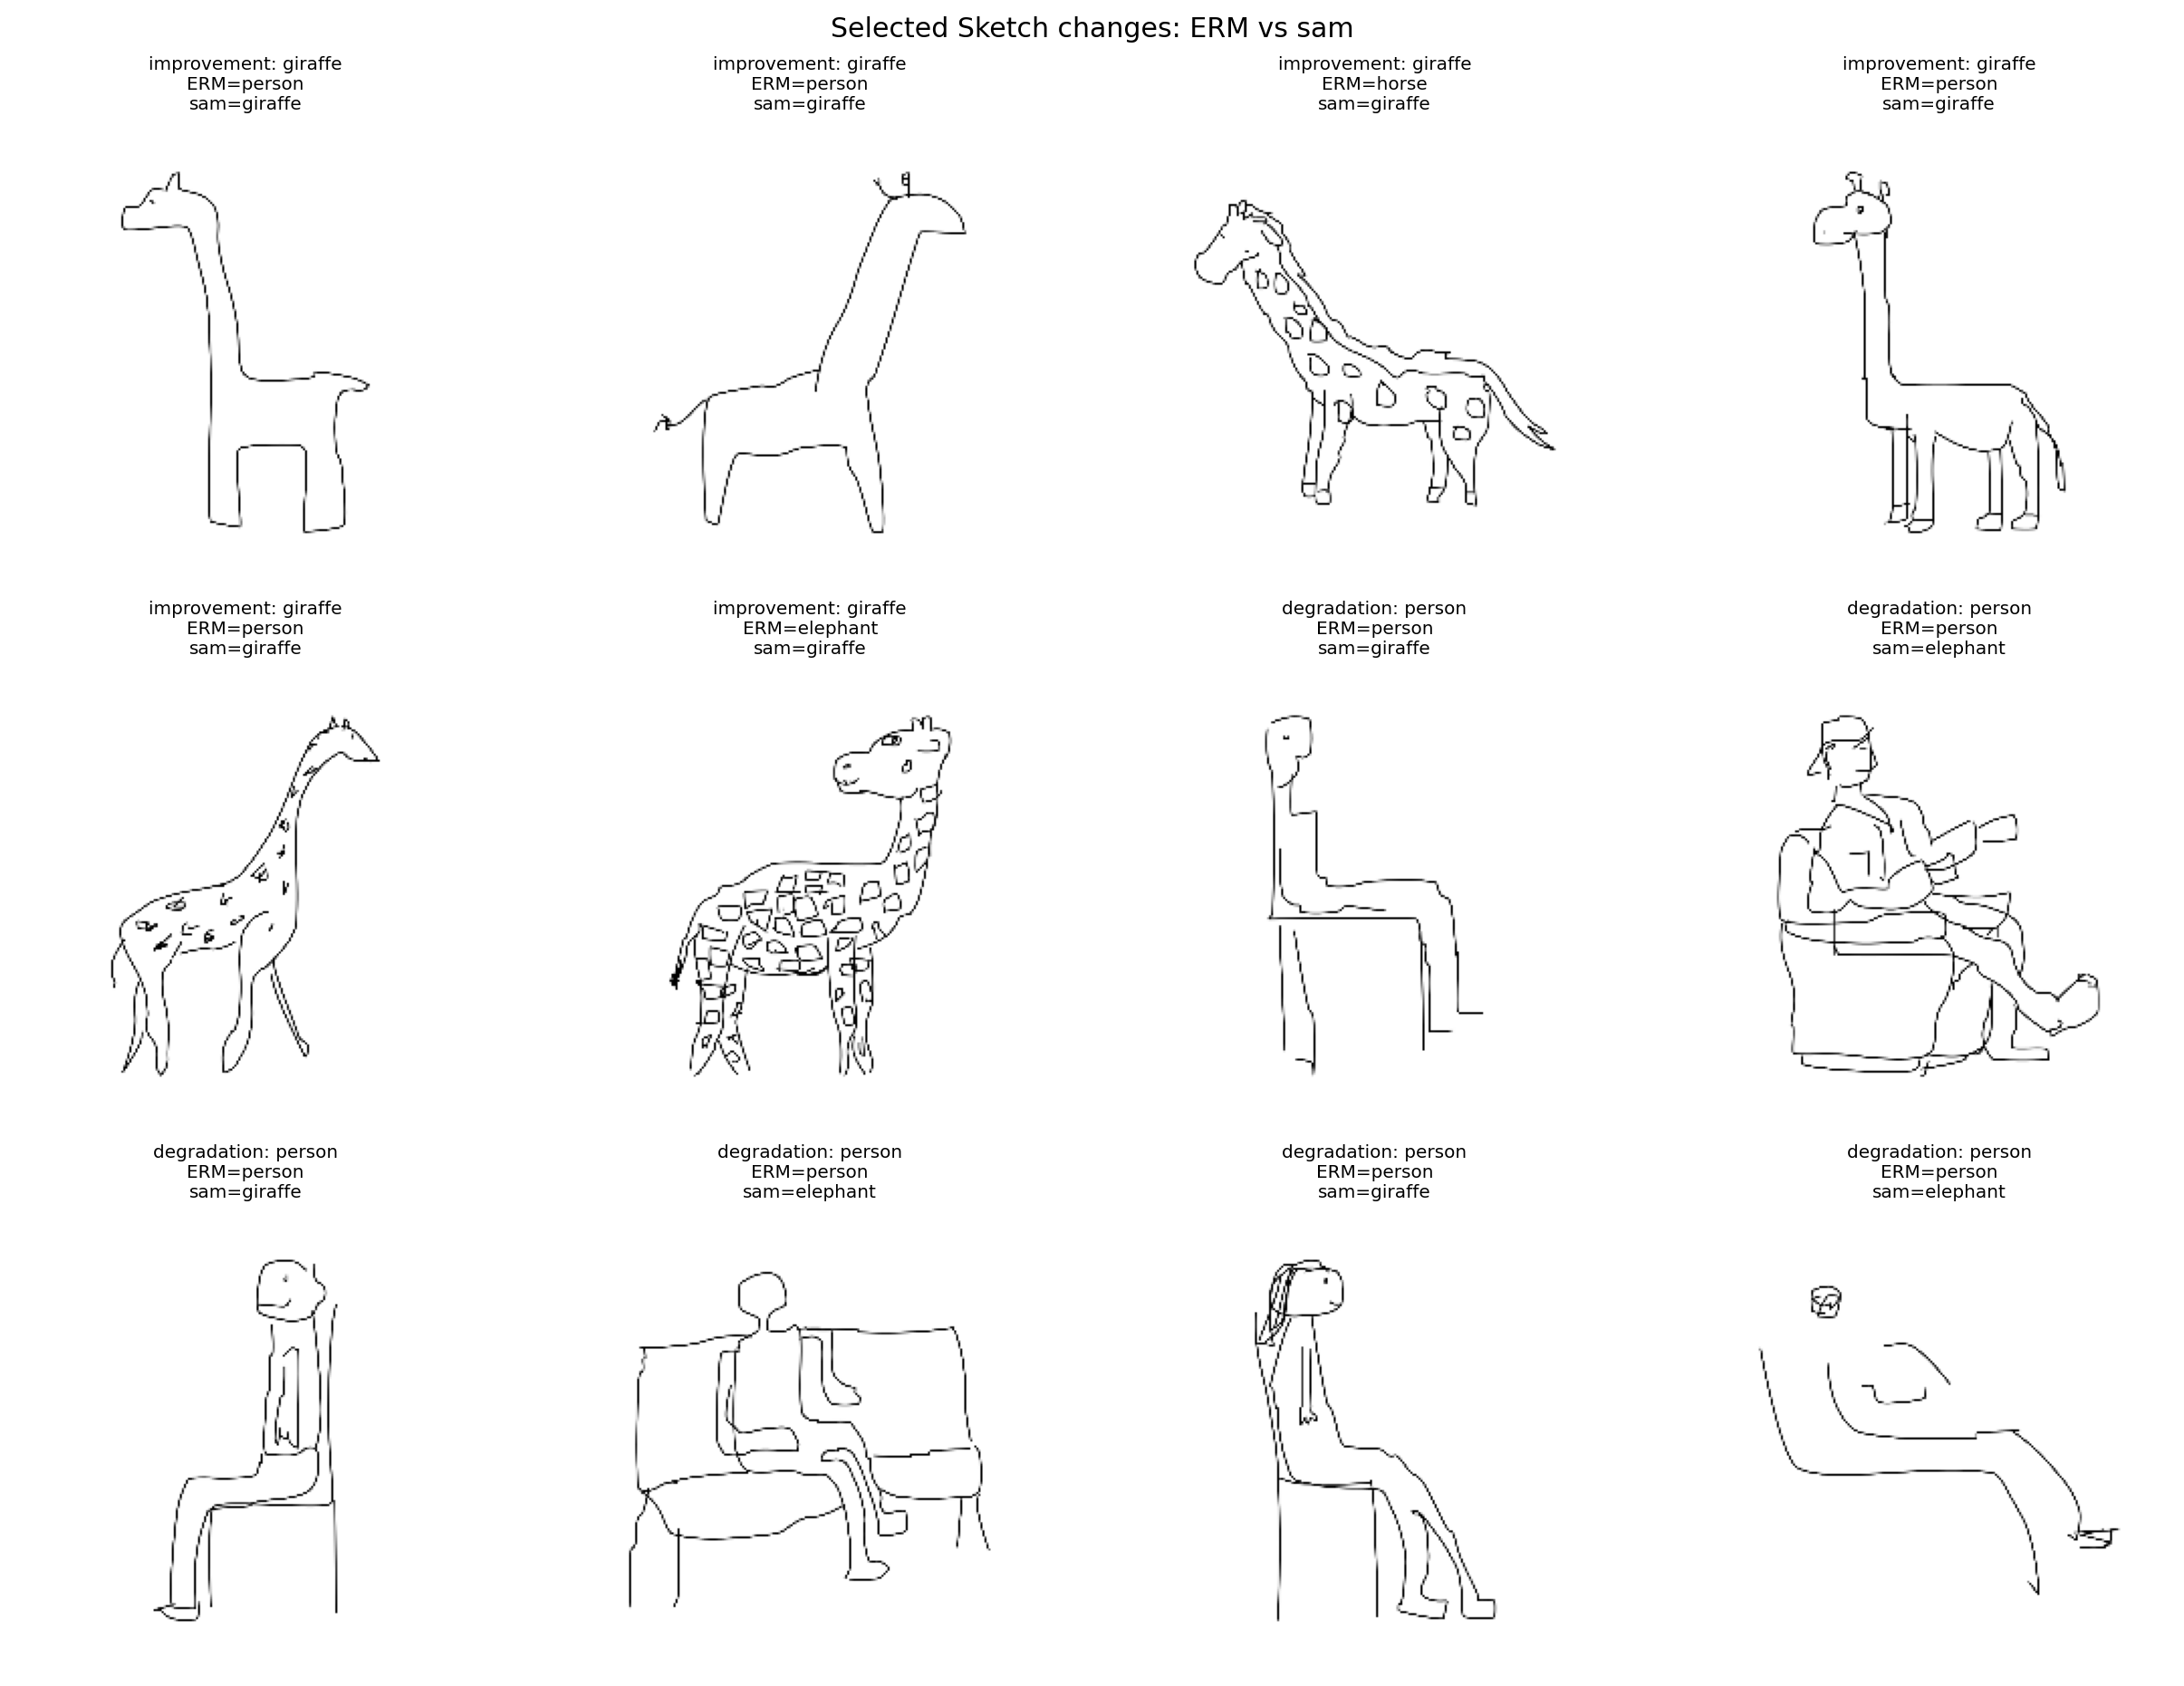

In [9]:
final = evaluate_sketch_suite(
    resolved_pacs_root, TASK_DIR, configurations_locked=CONFIGURATIONS_LOCKED
)
display(final["main_comparison"].round(4))
display(final["study"].round(4))
display(final["cross_task"].round(4))
display(DisplayImage(filename=str(TASK_DIR / "results/sketch_per_class_accuracy_changes.png"), width=950))
display(DisplayImage(filename=str(TASK_DIR / "results/sketch_confusion_matrices.png"), width=1200))
display(DisplayImage(filename=str(TASK_DIR / "results/selected_sketch_failure_cases.png"), width=1000))

In [10]:
import shutil
from IPython.display import FileLink, display
folder = "/kaggle/working/beyond-iid/domain-generalization/results"
zip_path = shutil.make_archive(folder, "zip", root_dir=folder)
display(FileLink(zip_path))

/kaggle/working/beyond-iid/domain-generalization/results.zip